# 07 — Experimentos de Arquitectura y Parámetros (v3)

Partiendo de las features y mejoras de v2, se prueban combinaciones sistemáticas de:

| Experimento | Variables | Opciones |
|---|---|---|
| Arquitectura (capas densas) | Tamaño de capas | 3 configuraciones |
| Dropout | Tasa de regularización | 2 niveles |
| Focal Loss γ | Parámetro de foco | 3 valores |
| Focal Loss α | Peso clase positiva | 3 valores |

Los resultados se guardan en `outputs/experimentos_v3.json`.  
El mejor modelo de cada tarea se guarda en `models/` como `_v3`.

**Baseline v2:** MAE=2.78d · R²=0.27 · AUC=0.66 · F1=0.095

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # Forzar CPU

import pandas as pd
import numpy as np
import json
import itertools
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, roc_auc_score, precision_recall_curve
)

print('TensorFlow:', tf.__version__)
print('Dispositivo:', 'CPU (GPU desactivada)')

DATA_DIR     = Path('../dataset')
MODELS_DIR   = Path('../models')
OUTPUTS_DIR  = Path('../outputs')
GRAFICAS_DIR = Path('../outputs/graficas')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
GRAFICAS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


TensorFlow: 2.21.0
Dispositivo: CPU (GPU desactivada)


## 1. Carga de datos y construcción del dataset v2

In [2]:
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv', parse_dates=[
    'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])
items     = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
products  = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
sellers   = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
geo       = pd.read_csv(DATA_DIR / 'olist_geolocation_dataset.csv')
cat_names = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

# Filtrar y calcular targets
df = orders[(orders['order_status'] == 'delivered') &
             orders['order_delivered_customer_date'].notna()].copy()
df['dias_entrega']  = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['es_retraso']    = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)
df = df[(df['dias_entrega'] >= 0) & (df['dias_entrega'] <= 60)]
df['dias_estimados'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

# Features temporales
df['mes_compra']        = df['order_purchase_timestamp'].dt.month
df['dia_semana_compra'] = df['order_purchase_timestamp'].dt.dayofweek
df['hora_compra']       = df['order_purchase_timestamp'].dt.hour

# Join items
items_agg = items.sort_values('price', ascending=False).groupby('order_id').agg(
    precio_total=('price','sum'), flete_total=('freight_value','sum'),
    product_id=('product_id','first'), seller_id=('seller_id','first'),
    n_items=('order_item_id','count'), shipping_limit_date=('shipping_limit_date','first')
).reset_index()
df = df.merge(items_agg, on='order_id', how='left')
df['dias_limite_envio'] = (df['shipping_limit_date'] - df['order_purchase_timestamp']).dt.days.clip(lower=0)

# Join productos
products = products.merge(cat_names, on='product_category_name', how='left')
df = df.merge(products[['product_id','product_category_name_english',
    'product_weight_g','product_length_cm','product_height_cm','product_width_cm']],
    on='product_id', how='left')
df.rename(columns={'product_category_name_english': 'categoria_producto'}, inplace=True)
df['volumen_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

# Join sellers y clientes
df = df.merge(sellers[['seller_id','seller_zip_code_prefix','seller_state']], on='seller_id', how='left')
df = df.merge(customers[['customer_id','customer_zip_code_prefix','customer_state']], on='customer_id', how='left')
df['mismo_estado'] = (df['seller_state'] == df['customer_state']).astype(int)

# Haversine
geo_agg = geo.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat','median'), lng=('geolocation_lng','median')).reset_index()
df = df.merge(geo_agg.rename(columns={'geolocation_zip_code_prefix':'seller_zip_code_prefix',
    'lat':'seller_lat','lng':'seller_lng'}), on='seller_zip_code_prefix', how='left')
df = df.merge(geo_agg.rename(columns={'geolocation_zip_code_prefix':'customer_zip_code_prefix',
    'lat':'customer_lat','lng':'customer_lng'}), on='customer_zip_code_prefix', how='left')

def haversine(lat1, lng1, lat2, lng2):
    R = 6371.0
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lng2-lng1)/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distancia_km'] = haversine(df['seller_lat'], df['seller_lng'],
                                df['customer_lat'], df['customer_lng'])
print(f'Dataset: {len(df):,} órdenes')

Dataset: 96,182 órdenes


In [3]:
FEATURES_NUM = [
    'distancia_km', 'precio_total', 'flete_total',
    'product_weight_g', 'volumen_cm3',
    'mes_compra', 'dia_semana_compra', 'hora_compra',
    'dias_estimados', 'dias_limite_envio', 'n_items', 'mismo_estado'
]
FEATURES_CAT = ['categoria_producto', 'customer_state', 'seller_state']
TARGETS      = ['dias_entrega', 'es_retraso']

df_modelo = df[FEATURES_NUM + FEATURES_CAT + TARGETS + ['order_purchase_timestamp']].copy()
for col in FEATURES_NUM:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())
for col in FEATURES_CAT:
    df_modelo[col] = df_modelo[col].fillna('desconocido')

# Split cronológico 80/10/10
df_modelo = df_modelo.sort_values('order_purchase_timestamp').reset_index(drop=True)
n = len(df_modelo)
n_train, n_val = int(n * 0.80), int(n * 0.90)
train = df_modelo.iloc[:n_train].copy()
val   = df_modelo.iloc[n_train:n_val].copy()
test  = df_modelo.iloc[n_val:].copy()

# Escalar y codificar
scaler = StandardScaler()
train[FEATURES_NUM] = scaler.fit_transform(train[FEATURES_NUM])
val[FEATURES_NUM]   = scaler.transform(val[FEATURES_NUM])
test[FEATURES_NUM]  = scaler.transform(test[FEATURES_NUM])

encoders, cardinalidades = {}, {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    le.fit(train[col])
    for split in [train, val, test]:
        split[col] = split[col].apply(lambda x: x if x in le.classes_ else 'desconocido')
    train[col] = le.transform(train[col])
    val[col]   = le.transform(val[col])
    test[col]  = le.transform(test[col])
    encoders[col] = le
    cardinalidades[col] = len(le.classes_)

def preparar_inputs(df):
    return [df[FEATURES_NUM].values.astype('float32')] + \
           [df[col].values.astype('int32') for col in FEATURES_CAT]

X_train = preparar_inputs(train);  X_val = preparar_inputs(val);  X_test = preparar_inputs(test)
y_train_reg = train['dias_entrega'].values.astype('float32')
y_val_reg   = val['dias_entrega'].values.astype('float32')
y_test_reg  = test['dias_entrega'].values.astype('float32')
y_train_clf = train['es_retraso'].values.astype('float32')
y_val_clf   = val['es_retraso'].values.astype('float32')
y_test_clf  = test['es_retraso'].values.astype('float32')

print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')
print(f'Cardinalidades: {cardinalidades}')

Train: 76,945 | Val: 9,618 | Test: 9,619
Cardinalidades: {'categoria_producto': 72, 'customer_state': 27, 'seller_state': 22}


## 2. Funciones auxiliares (arquitectura + Focal Loss)

In [4]:
def construir_modelo(cards, n_num, capas, dropout, activacion_salida, nombre_salida):
    """
    Construye un modelo Feed-Forward con Embeddings.
    capas:   lista de enteros, ej. [256,128,64]
    dropout: (drop_primera, drop_resto), ej. (0.3, 0.2)
    """
    inp_num = keras.Input(shape=(n_num,), name='input_numerico')
    emb_inputs, emb_outputs = [], []
    for col, card in cards.items():
        dim = min(50, (card // 2) + 1)
        inp = keras.Input(shape=(1,), name=f'input_{col}', dtype='int32')
        emb = layers.Embedding(input_dim=card, output_dim=dim, name=f'emb_{col}')(inp)
        emb = layers.Flatten()(emb)
        emb_inputs.append(inp)
        emb_outputs.append(emb)

    x = layers.Concatenate()([inp_num] + emb_outputs)
    for i, unidades in enumerate(capas):
        x = layers.Dense(unidades, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(dropout[0] if i == 0 else dropout[1])(x)

    salida = layers.Dense(1, activation=activacion_salida, name=nombre_salida)(x)
    return keras.Model(inputs=[inp_num] + emb_inputs, outputs=salida)


def focal_loss(gamma=2.0, alpha=0.75):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)
        return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)
    return loss


def umbral_optimo(modelo, X_val, y_val):
    """Devuelve el umbral que maximiza F1 sobre validación."""
    probs = modelo.predict(X_val, verbose=0).flatten()
    prec, rec, thr = precision_recall_curve(y_val, probs)
    f1s = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    return float(thr[np.argmax(f1s)])


CALLBACKS_BASE = lambda monitor, mode='min': [
    keras.callbacks.EarlyStopping(monitor=monitor, patience=8,
        restore_best_weights=True, mode=mode, verbose=0),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0)
]

print('Funciones definidas.')

Funciones definidas.


## 3. Experimentos — Regresión

Grid de búsqueda:
- **Arquitectura:** 3 configuraciones de capas densas
- **Dropout:** 2 niveles (bajo / alto)

Total: **6 experimentos de regresión**

In [5]:
import gc

GRID_CAPAS = [
    [256, 128, 64],    # v2 base (pirámide estándar)
    [128, 64, 32],     # más pequeña
    [512, 256, 128],   # más grande
]
GRID_DROPOUT = [
    (0.2, 0.1),   # bajo
    (0.3, 0.2),   # v2 base
]

resultados_reg = []

for capas, drop in itertools.product(GRID_CAPAS, GRID_DROPOUT):
    nombre = f"capas={'_'.join(map(str,capas))}_drop={drop[0]}"
    print(f"  Entrenando: {nombre} ...", end=' ')

    modelo = construir_modelo(cardinalidades, len(FEATURES_NUM),
                              capas, drop, 'linear', 'dias_entrega')
    modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mae', metrics=['mae'])

    modelo.fit(X_train, y_train_reg,
               validation_data=(X_val, y_val_reg),
               epochs=80, batch_size=256,
               callbacks=CALLBACKS_BASE('val_loss', 'min'), verbose=0)

    pred = modelo.predict(X_test, verbose=0).flatten()
    mae  = mean_absolute_error(y_test_reg, pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, pred))
    r2   = r2_score(y_test_reg, pred)

    resultados_reg.append({
        'nombre': nombre, 'capas': capas, 'dropout': list(drop),
        'mae': round(mae, 4), 'rmse': round(rmse, 4), 'r2': round(r2, 4)
    })
    print(f"MAE={mae:.3f} | R²={r2:.4f}")

    del modelo
    gc.collect()

df_reg = pd.DataFrame(resultados_reg).sort_values('mae')
print('\n=== Resultados regresión ===')
print(df_reg[['nombre','mae','rmse','r2']].to_string(index=False))


  Entrenando: capas=256_128_64_drop=0.2 ... WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
MAE=2.889 | R²=0.2248
  Entrenando: capas=256_128_64_drop=0.3 ... MAE=2.679 | R²=0.3010
  Entrenando: capas=128_64_32_drop=0.2 ... MAE=2.963 | R²=0.2144
  Entrenando: capas=128_64_32_drop=0.3 ... MAE=2.954 | R²=0.2112
  Entrenando: capas=512_256_128_drop=0.2 ... MAE=2.851 | R²=0.2416
  Entrenando: capas=512_256_128_drop=0.3 ... MAE=2.881 | R²=0.2495

=== Resultados regresión ===
                    nombre    mae   rmse     r2
 capas=256_128_64_drop=0.3 2.6787 3.9921 0.3010
capas=512_256_128_drop=0.2 2.8513 4.1580 0.2416
capas=512_256_128_drop=0.3 2.8809 4.1366 0.2495
 capas=256_128_64_drop=0.2 2.8891 4.2040 0.2248
  capas=128_64_32_drop=0.3 2.9539 4.2406 0.2112
  capas=128_64_32_drop=0.2 2.9634 4.2320 0.2144


## 4. Experimentos — Clasificación (Focal Loss)

Grid de búsqueda:
- **γ (gamma):** fuerza del foco sobre ejemplos difíciles
- **α (alpha):** peso de la clase positiva (retrasos)

Total: **9 experimentos de clasificación**

In [6]:
GRID_GAMMA = [1.0, 2.0, 3.0]
GRID_ALPHA = [0.5, 0.75, 0.9]

# Usar la mejor arquitectura de regresión para clasificación también
mejor_reg = df_reg.iloc[0]
best_capas   = mejor_reg['capas']
best_dropout = tuple(mejor_reg['dropout'])

resultados_clf = []

for gamma, alpha in itertools.product(GRID_GAMMA, GRID_ALPHA):
    nombre = f"gamma={gamma}_alpha={alpha}"
    print(f"  Entrenando: {nombre} ...", end=' ')

    modelo = construir_modelo(cardinalidades, len(FEATURES_NUM),
                              best_capas, best_dropout, 'sigmoid', 'es_retraso')
    modelo.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=focal_loss(gamma=gamma, alpha=alpha),
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )

    modelo.fit(X_train, y_train_clf,
               validation_data=(X_val, y_val_clf),
               epochs=80, batch_size=256,
               callbacks=CALLBACKS_BASE('val_auc', 'max'), verbose=0)

    thr = umbral_optimo(modelo, X_val, y_val_clf)
    probs_test = modelo.predict(X_test, verbose=0).flatten()
    preds_test = (probs_test >= thr).astype(int)

    auc = roc_auc_score(y_test_clf, probs_test)
    f1  = f1_score(y_test_clf, preds_test)

    resultados_clf.append({
        'nombre': nombre, 'gamma': gamma, 'alpha': alpha,
        'umbral': round(thr, 4),
        'auc': round(auc, 4), 'f1': round(f1, 4)
    })
    print(f"AUC={auc:.4f} | F1={f1:.4f} | umbral={thr:.3f}")

    del modelo
    gc.collect()

df_clf = pd.DataFrame(resultados_clf).sort_values('f1', ascending=False)
print('\n=== Resultados clasificación ===')
print(df_clf[['nombre','auc','f1','umbral']].to_string(index=False))


  Entrenando: gamma=1.0_alpha=0.5 ... AUC=0.5778 | F1=0.0626 | umbral=0.366
  Entrenando: gamma=1.0_alpha=0.75 ... AUC=0.6743 | F1=0.1096 | umbral=0.477
  Entrenando: gamma=1.0_alpha=0.9 ... AUC=0.6187 | F1=0.0989 | umbral=0.662
  Entrenando: gamma=2.0_alpha=0.5 ... AUC=0.5883 | F1=0.1124 | umbral=0.380
  Entrenando: gamma=2.0_alpha=0.75 ... AUC=0.6619 | F1=0.0643 | umbral=0.513
  Entrenando: gamma=2.0_alpha=0.9 ... AUC=0.6281 | F1=0.0928 | umbral=0.637
  Entrenando: gamma=3.0_alpha=0.5 ... AUC=0.6365 | F1=0.0983 | umbral=0.425
  Entrenando: gamma=3.0_alpha=0.75 ... AUC=0.6486 | F1=0.1101 | umbral=0.470
  Entrenando: gamma=3.0_alpha=0.9 ... AUC=0.6284 | F1=0.0789 | umbral=0.599

=== Resultados clasificación ===
              nombre    auc     f1  umbral
 gamma=2.0_alpha=0.5 0.5883 0.1124  0.3799
gamma=3.0_alpha=0.75 0.6486 0.1101  0.4700
gamma=1.0_alpha=0.75 0.6743 0.1096  0.4771
 gamma=1.0_alpha=0.9 0.6187 0.0989  0.6620
 gamma=3.0_alpha=0.5 0.6365 0.0983  0.4245
 gamma=2.0_alpha=0.9 

## 5. Reentrenar mejores modelos y guardar como v3

In [7]:
# --- Mejor configuración de regresión ---
mejor_reg = df_reg.iloc[0]
print(f"Mejor regresión: {mejor_reg['nombre']}  (MAE={mejor_reg['mae']}, R²={mejor_reg['r2']})")

modelo_reg_v3 = construir_modelo(
    cardinalidades, len(FEATURES_NUM),
    mejor_reg['capas'], tuple(mejor_reg['dropout']),
    'linear', 'dias_entrega'
)
modelo_reg_v3.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mae', metrics=['mae'])
modelo_reg_v3.fit(X_train, y_train_reg,
                  validation_data=(X_val, y_val_reg),
                  epochs=100, batch_size=256,
                  callbacks=CALLBACKS_BASE('val_loss', 'min'), verbose=1)

pred_reg_v3 = modelo_reg_v3.predict(X_test, verbose=0).flatten()
mae_v3  = mean_absolute_error(y_test_reg, pred_reg_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test_reg, pred_reg_v3))
r2_v3   = r2_score(y_test_reg, pred_reg_v3)
print(f'\nRegresión v3 → MAE={mae_v3:.4f} | RMSE={rmse_v3:.4f} | R²={r2_v3:.4f}')

modelo_reg_v3.save(MODELS_DIR / 'modelo_regresion_v3.keras')
print('Guardado: models/modelo_regresion_v3.keras')


Mejor regresión: capas=256_128_64_drop=0.3  (MAE=2.6787, R²=0.301)
Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 9.2008 - mae: 9.2008 - val_loss: 3.3821 - val_mae: 3.3821 - learning_rate: 0.0010
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.1469 - mae: 5.1469 - val_loss: 3.6381 - val_mae: 3.6381 - learning_rate: 0.0010
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.0164 - mae: 5.0164 - val_loss: 3.4885 - val_mae: 3.4885 - learning_rate: 0.0010
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.9593 - mae: 4.9593 - val_loss: 3.4786 - val_mae: 3.4786 - learning_rate: 0.0010
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.9224 - mae: 4.9224 - val_loss: 3.4003 - val_mae: 3.4003 - learning_rate: 0.0010
Epoch 6/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.8884 - mae: 4.8884 - val_loss: 3.4493 - val_mae: 3.4493 - learning_rate: 5.0000e-04
Epoch 7/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.8538 - m

In [8]:
# --- Mejor configuración de clasificación ---
mejor_clf = df_clf.iloc[0]
print(f"Mejor clasificación: {mejor_clf['nombre']}  (AUC={mejor_clf['auc']}, F1={mejor_clf['f1']})")

modelo_clf_v3 = construir_modelo(
    cardinalidades, len(FEATURES_NUM),
    mejor_reg['capas'], tuple(mejor_reg['dropout']),
    'sigmoid', 'es_retraso'
)
modelo_clf_v3.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=focal_loss(gamma=mejor_clf['gamma'], alpha=mejor_clf['alpha']),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
modelo_clf_v3.fit(X_train, y_train_clf,
                  validation_data=(X_val, y_val_clf),
                  epochs=100, batch_size=256,
                  callbacks=CALLBACKS_BASE('val_auc', 'max'), verbose=1)

umbral_v3     = umbral_optimo(modelo_clf_v3, X_val, y_val_clf)
probs_clf_v3  = modelo_clf_v3.predict(X_test, verbose=0).flatten()
preds_clf_v3  = (probs_clf_v3 >= umbral_v3).astype(int)
auc_v3  = roc_auc_score(y_test_clf, probs_clf_v3)
f1_v3   = f1_score(y_test_clf, preds_clf_v3)
print(f'\nClasificación v3 → AUC={auc_v3:.4f} | F1={f1_v3:.4f} | umbral={umbral_v3:.4f}')

modelo_clf_v3.save(MODELS_DIR / 'modelo_clasificacion_v3.keras')
print('Guardado: models/modelo_clasificacion_v3.keras')


Mejor clasificación: gamma=2.0_alpha=0.5  (AUC=0.5883, F1=0.1124)
Epoch 1/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8209 - auc: 0.5641 - loss: 0.0664 - val_accuracy: 0.9807 - val_auc: 0.6943 - val_loss: 0.0190 - learning_rate: 0.0010
Epoch 2/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9082 - auc: 0.6453 - loss: 0.0425 - val_accuracy: 0.9808 - val_auc: 0.7478 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 3/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9112 - auc: 0.6875 - loss: 0.0392 - val_accuracy: 0.9808 - val_auc: 0.7487 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 4/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9131 - auc: 0.7071 - loss: 0.0376 - val_accuracy: 0.9808 - val_auc: 0.7741 - val_loss: 0.0143 - learning_rate: 0.0010
Epoch 5/100
301/301 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9137 - auc: 0.7297 - loss: 0.0364 - val_accuracy: 0.9808 - val_auc: 0.7737 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 6/1

## 6. Visualización de resultados de experimentos

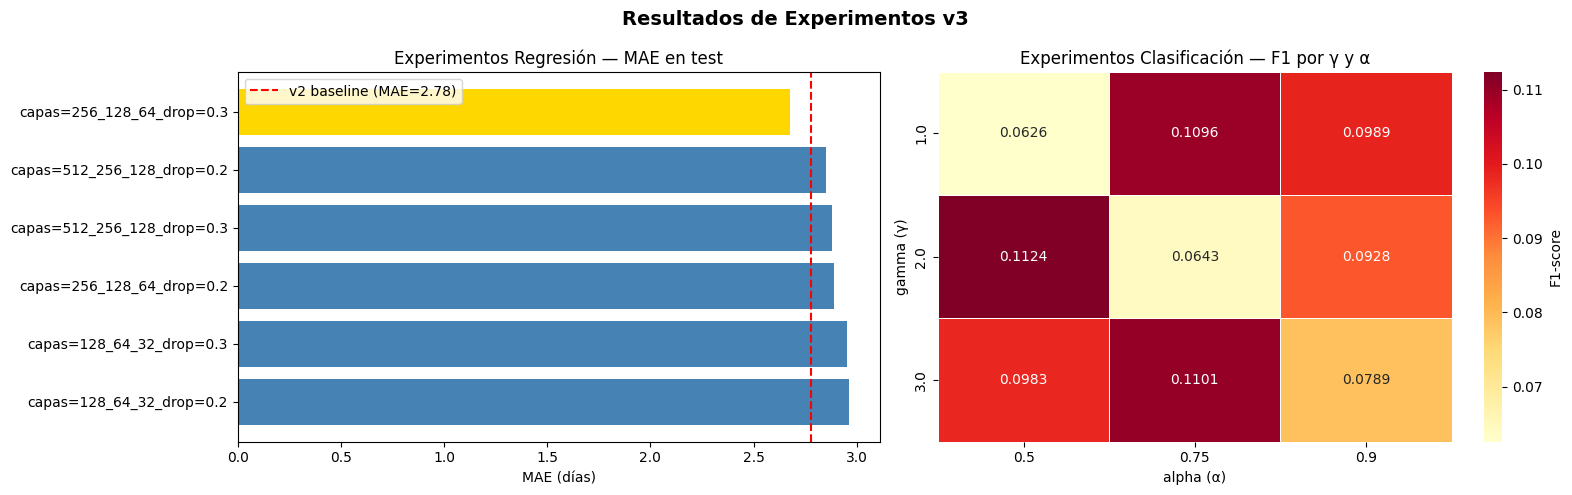

Guardado: outputs/graficas/experimentos_v3.png


In [9]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Panel 1: MAE por experimento de regresión ---
ax = axes[0]
colores = ['gold' if i == 0 else 'steelblue' for i in range(len(df_reg))]
ax.barh(df_reg['nombre'], df_reg['mae'], color=colores)
ax.axvline(2.7769, color='red', linestyle='--', linewidth=1.5, label='v2 baseline (MAE=2.78)')
ax.set_xlabel('MAE (días)')
ax.set_title('Experimentos Regresión — MAE en test')
ax.legend()
ax.invert_yaxis()

# --- Panel 2: F1-score por experimento de clasificación ---
ax = axes[1]
# Heatmap gamma vs alpha
pivot = df_clf.pivot(index='gamma', columns='alpha', values='f1')
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'F1-score'})
ax.set_title('Experimentos Clasificación — F1 por γ y α')
ax.set_xlabel('alpha (α)')
ax.set_ylabel('gamma (γ)')

plt.suptitle('Resultados de Experimentos v3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAFICAS_DIR / 'experimentos_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: outputs/graficas/experimentos_v3.png")

## 7. Guardar resultados completos en JSON

In [10]:
metricas_v3 = {
    "regresion": {
        "mae_dias":  round(mae_v3,  4),
        "rmse_dias": round(rmse_v3, 4),
        "r2":        round(r2_v3,   4),
        "mejor_config": {
            "capas":   mejor_reg['capas'],
            "dropout": mejor_reg['dropout'],
        }
    },
    "clasificacion": {
        "auc_roc":       round(auc_v3, 4),
        "f1_score":      round(f1_v3,  4),
        "umbral_optimo": round(umbral_v3, 4),
        "n_retrasos_reales":    int(y_test_clf.sum()),
        "n_retrasos_predichos": int(preds_clf_v3.sum()),
        "mejor_config": {
            "gamma": mejor_clf['gamma'],
            "alpha": mejor_clf['alpha'],
        }
    },
    "experimentos": {
        "regresion":     resultados_reg,
        "clasificacion": resultados_clf,
    }
}

with open(OUTPUTS_DIR / 'metricas_v3.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_v3, f, ensure_ascii=False, indent=2)

print("Guardado: outputs/metricas_v3.json")
print(json.dumps({k: v for k, v in metricas_v3.items() if k != 'experimentos'}, indent=2))

Guardado: outputs/metricas_v3.json
{
  "regresion": {
    "mae_dias": 2.7051,
    "rmse_dias": 3.9606,
    "r2": 0.312,
    "mejor_config": {
      "capas": [
        256,
        128,
        64
      ],
      "dropout": [
        0.3,
        0.2
      ]
    }
  },
  "clasificacion": {
    "auc_roc": 0.6131,
    "f1_score": 0.0936,
    "umbral_optimo": 0.3973,
    "n_retrasos_reales": 822,
    "n_retrasos_predichos": 609,
    "mejor_config": {
      "gamma": 2.0,
      "alpha": 0.5
    }
  }
}


## 8. Tabla comparativa v1 → v2 → v3

In [11]:
with open(OUTPUTS_DIR / 'metricas.json', 'r') as f:
    m1 = json.load(f)
with open(OUTPUTS_DIR / 'metricas_v2.json', 'r') as f:
    m2 = json.load(f)

tabla = pd.DataFrame({
    'Modelo':        ['Regresión']*3    + ['Clasificación']*2,
    'Métrica':       ['MAE','RMSE','R²','AUC-ROC','F1-score'],
    'v1 (baseline)': [m1['regresion']['mae_dias'],  m1['regresion']['rmse_dias'],
                      m1['regresion']['r2'],
                      m1['clasificacion']['auc_roc'], m1['clasificacion']['f1_score']],
    'v2 (features)': [m2['regresion']['mae_dias'],  m2['regresion']['rmse_dias'],
                      m2['regresion']['r2'],
                      m2['clasificacion']['auc_roc'], m2['clasificacion']['f1_score']],
    'v3 (experim.)': [mae_v3, rmse_v3, r2_v3, auc_v3, f1_v3],
})

pd.set_option('display.float_format', '{:.4f}'.format)
print(tabla.to_string(index=False))

       Modelo  Métrica  v1 (baseline)  v2 (features)  v3 (experim.)
    Regresión      MAE         3.2555         2.7769         2.7051
    Regresión     RMSE         4.3901         4.0796         3.9606
    Regresión       R²         0.1546         0.2700         0.3120
Clasificación  AUC-ROC         0.5565         0.6624         0.6131
Clasificación F1-score         0.0326         0.0952         0.0936
